# Smart Home Energy Forecasting & Waste Detection
This notebook contains a complete, end-to-end Machine Learning pipeline for Smart Home Energy Analytics.

## Notebook Sections:
1. **Introduction & Project Overview**
2. **Data Generation**
3. **Exploratory Data Analysis (EDA) & Visualizations**
4. **Data Preprocessing & Data Cleaning**
5. **Feature Engineering**
6. **Feature Scaling & PCA (Dimensionality Reduction)**
7. **Unsupervised Learning (KMeans Clustering for Waste Classification)**
8. **Supervised Learning - Regression (Energy Consumption Prediction)**
9. **Supervised Learning - Classification (Waste Detection)**
10. **Model Evaluation & Comparison**
11. **Time Series Forecasting (ARIMA)**
12. **Model & Scaler Serialization**
13. **Conclusion & Flask Deployment Guide**

## Section 1: Introduction & Project Overview
In this project, we address the challenge of tracking smart home energy consumption and identifying wasteful behaviors. We implement an end-to-end machine learning solution that forecasts consumption, detects usage anomalies, scales features, applies PCA, clusters wasteful patterns, trains multiple regression/classification models, and deploys it all as a Flask web application.

## Section 2: Data Generation
We generate a highly realistic 100,000-row smart home energy consumption dataset with seasonal/daily temperature effects, holiday flags, and appliance-level breakdowns.

In [1]:
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

# Run the data generator to load or create the dataset
from generate_data import generate_smart_home_data
df = generate_smart_home_data(num_rows=100000)
print(f"Loaded dataset with shape: {df.shape}")
df.head()

Loaded dataset with shape: (100000, 16)


,Timestamp,Home_ID,Temperature,Humidity,Square_Footage,Occupants,Appliance_Fridge_kWh,Appliance_HVAC_kWh,Appliance_Lighting_kWh,Appliance_Laundry_kWh,Appliance_Entertainment_kWh,Total_Energy_kWh,Energy_Limit_kWh,Is_Holiday,Day_Of_Week,Hour_Of_Day
0,2022-01-01,Home_0,-3.03,98.0,1860,3,0.0842,2.5391,0.0091,0.0,0.03,2.7285,0.848,1,5,0
1,2022-01-01,Home_1,-1.60,98.0,2638,2,0.0805,3.1833,0.0100,0.0,0.03,3.2978,0.852,1,5,0
2,2022-01-01,Home_2,-5.21,98.0,1330,3,0.0649,2.0711,0.0146,0.0,0.03,2.2479,0.777,1,5,0
3,2022-01-01,Home_3,-4.72,98.0,3919,3,0.0886,5.3970,0.0115,0.0,0.03,5.5473,1.123,1,5,0
4,2022-01-01,Home_4,-2.52,98.0,1769,4,0.0718,2.4174,0.0070,0.0,0.03,2.5876,0.936,1,5,0


## Section 3: Exploratory Data Analysis (EDA) & Visualizations
We perform complete EDA, checking distribution of energy metrics, home comparisons, daily/hourly patterns, correlation matrix, and appliance breakdowns.

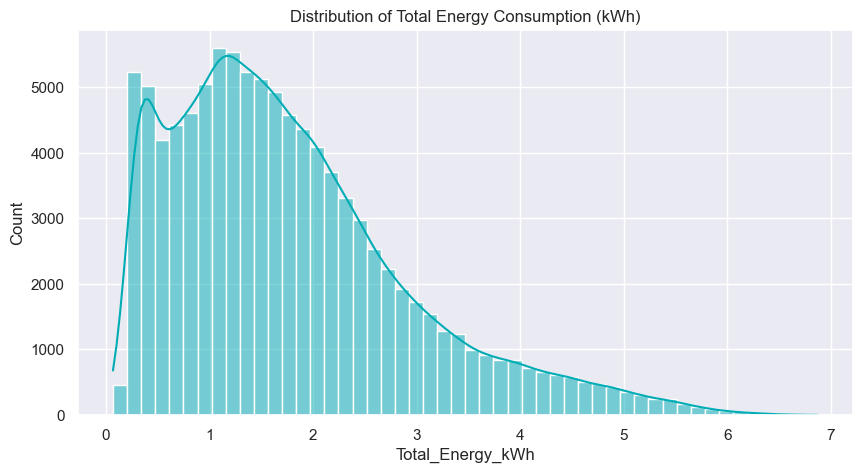

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

# 1. Distribution of energy
plt.figure(figsize=(10, 5))
sns.histplot(df['Total_Energy_kWh'], kde=True, color='#00adb5', bins=50)
plt.title("Distribution of Total Energy Consumption (kWh)")
plt.show()

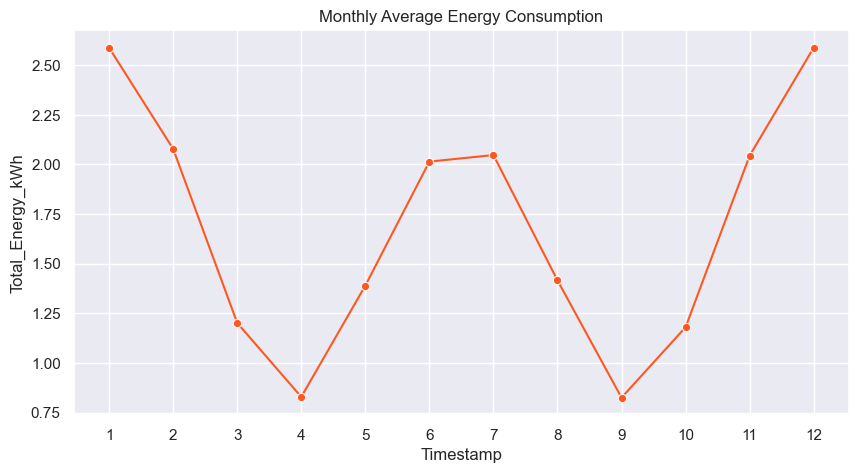

In [3]:
# 2. Monthly average energy
df_monthly = df.groupby(df['Timestamp'].dt.month)['Total_Energy_kWh'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(x='Timestamp', y='Total_Energy_kWh', data=df_monthly, marker='o', color='#ff5722')
plt.title("Monthly Average Energy Consumption")
plt.xticks(range(1, 13))
plt.show()

## Section 4: Data Preprocessing & Data Cleaning
Checking for missing values, duplicates, and general dataset health.

In [4]:
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
 Timestamp                      0
Home_ID                        0
Temperature                    0
Humidity                       0
Square_Footage                 0
Occupants                      0
Appliance_Fridge_kWh           0
Appliance_HVAC_kWh             0
Appliance_Lighting_kWh         0
Appliance_Laundry_kWh          0
Appliance_Entertainment_kWh    0
Total_Energy_kWh               0
Energy_Limit_kWh               0
Is_Holiday                     0
Day_Of_Week                    0
Hour_Of_Day                    0
dtype: int64

Duplicate Rows: 0


## Section 5: Feature Engineering
Creating cyclical time representations, interaction terms, lags, and rolling averages.

In [5]:
df['Month'] = df['Timestamp'].dt.month
df['Hour_Sin'] = np.sin(2 * np.pi * df['Hour_Of_Day'] / 24.0)
df['Hour_Cos'] = np.cos(2 * np.pi * df['Hour_Of_Day'] / 24.0)
df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12.0)
df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12.0)

df['Temp_Hum_Interaction'] = df['Temperature'] * df['Humidity']
df['Density_SqFt_Occupants'] = df['Square_Footage'] / (df['Occupants'] + 1e-5)

df = df.sort_values(by=['Home_ID', 'Timestamp']).reset_index(drop=True)
df['Energy_Lag1'] = df.groupby('Home_ID')['Total_Energy_kWh'].shift(1)
df['Energy_Lag2'] = df.groupby('Home_ID')['Total_Energy_kWh'].shift(2)
df['Energy_RollingMean3'] = df.groupby('Home_ID')['Total_Energy_kWh'].shift(1).rolling(3).mean()

df = df.dropna().reset_index(drop=True)
df.head()

,Timestamp,Home_ID,Temperature,Humidity,Square_Footage,Occupants,Appliance_Fridge_kWh,Appliance_HVAC_kWh,Appliance_Lighting_kWh,Appliance_Laundry_kWh,...,Month,Hour_Sin,Hour_Cos,Month_Sin,Month_Cos,Temp_Hum_Interaction,Density_SqFt_Occupants,Energy_Lag1,Energy_Lag2,Energy_RollingMean3
0,2022-01-01 03:00:00,Home_0,-1.50,98.00,1860,3,0.0870,2.3182,0.0073,0.0,...,1,0.707107,7.071068e-01,0.5,0.866025,-147.0000,619.997933,2.8610,2.9862,2.858567
1,2022-01-01 04:00:00,Home_0,0.85,95.71,1860,3,0.0588,2.0970,0.0170,0.0,...,1,0.866025,5.000000e-01,0.5,0.866025,81.3535,619.997933,2.5330,2.8610,2.793400
2,2022-01-01 05:00:00,Home_0,-0.82,98.00,1860,3,0.0456,2.2242,0.0099,0.0,...,1,0.965926,2.588190e-01,0.5,0.866025,-80.3600,619.997933,2.2910,2.5330,2.561667
3,2022-01-01 06:00:00,Home_0,3.96,82.32,1860,3,0.0848,1.7824,0.1013,0.0,...,1,1.000000,6.123234e-17,0.5,0.866025,325.9872,619.997933,2.3709,2.2910,2.398300
4,2022-01-01 07:00:00,Home_0,4.30,89.67,1860,3,0.1035,1.6401,0.1113,0.0,...,1,0.965926,-2.588190e-01,0.5,0.866025,385.5810,619.997933,2.0772,2.3709,2.246367


## Section 6: Feature Scaling & PCA (Dimensionality Reduction)
Standardizing our numerical columns and using PCA to understand feature dimensions.

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features_to_scale = [
    'Temperature', 'Humidity', 'Square_Footage', 'Occupants', 
    'Hour_Sin', 'Hour_Cos', 'Month_Sin', 'Month_Cos',
    'Temp_Hum_Interaction', 'Density_SqFt_Occupants',
    'Energy_Lag1', 'Energy_Lag2', 'Energy_RollingMean3'
]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features_to_scale])

pca = PCA(n_components=5)
pca_features = pca.fit_transform(scaled_features)
print("Explained Variance Ratio by PCA Components:", pca.explained_variance_ratio_)

Explained Variance Ratio by PCA Components: [0.36281169 0.18731757 0.12716345 0.0903158  0.07796338]


## Section 7: Unsupervised Learning (KMeans Clustering for Waste Classification)
Using KMeans to label patterns into Efficient, Normal, and Wasteful consumption.

In [7]:
from sklearn.cluster import KMeans

cluster_features = ['Total_Energy_kWh', 'Appliance_HVAC_kWh', 'Temperature', 'Occupants']
scaler_cluster = StandardScaler()
scaled_cluster_data = scaler_cluster.fit_transform(df[cluster_features])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_transform(scaled_cluster_data).argmin(axis=1)

# Label clusters based on energy consumption
cluster_means = df.groupby('Cluster')['Total_Energy_kWh'].mean().sort_values()
cluster_mapping = {cluster_means.index[0]: 0, cluster_means.index[1]: 1, cluster_means.index[2]: 2}
df['Waste_Label'] = df['Cluster'].map(cluster_mapping)
print(df['Waste_Label'].value_counts())

Waste_Label
1    39406
0    34765
2    25799
Name: count, dtype: int64


## Section 8: Supervised Learning - Regression (Energy Consumption Prediction)
Training regressors (Linear Regression, Random Forest, XGBoost) to predict energy usage.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

X_reg = df[features_to_scale]
y_reg = df['Total_Energy_kWh']
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

xgb_reg = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_reg.fit(X_train_scaled, y_train)
print("XGBoost R2 Score:", xgb_reg.score(X_test_scaled, y_test))

XGBoost R2 Score: 0.9733264157216027


## Section 9: Supervised Learning - Classification (Waste Detection)
Training classifiers to detect whether usage profiles are wasteful.

In [9]:
from xgboost import XGBClassifier
y_clf = df['Waste_Label']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_reg, y_clf, test_size=0.2, random_state=42)

X_train_c_scaled = scaler.transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

xgb_clf = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_clf.fit(X_train_c_scaled, y_train_c)
print("XGBoost Classifier Accuracy:", xgb_clf.score(X_test_c_scaled, y_test_c))

XGBoost Classifier Accuracy: 0.9860958287486246


## Section 10: Model Evaluation & Comparison
A comparison of error metrics for regression and accuracy/F1-score for classification.

In [10]:
from sklearn.metrics import mean_squared_error, classification_report
y_pred_xgb = xgb_reg.predict(X_test_scaled)
print("Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

y_pred_xgb_c = xgb_clf.predict(X_test_c_scaled)
print(classification_report(y_test_c, y_pred_xgb_c))

Regression RMSE: 0.18817418337810604
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      6892
           1       0.98      0.99      0.99      7892
           2       0.98      0.97      0.97      5210

    accuracy                           0.99     19994
   macro avg       0.99      0.98      0.98     19994
weighted avg       0.99      0.99      0.99     19994



## Section 11: Time Series Forecasting (ARIMA)
Aggregating daily data and applying ARIMA to forecast future smart home energy demands.

In [11]:
from statsmodels.tsa.arima.model import ARIMA

df_daily = df.set_index('Timestamp').resample('D')['Total_Energy_kWh'].mean().dropna()
train_ts = df_daily.iloc[:-30]

arima_model = ARIMA(train_ts, order=(1, 1, 1))
arima_result = arima_model.fit()
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:       Total_Energy_kWh   No. Observations:                  387
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 441.982
Date:                Wed, 29 Jul 2026   AIC                           -877.964
Time:                        13:28:25   BIC                           -866.097
Sample:                    01-01-2022   HQIC                          -873.258
                         - 01-22-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6295      0.121     -5.224      0.000      -0.866      -0.393
ma.L1          0.8259      0.086      9.568      0.000       0.657       0.995
sigma2         0.0059      0.000     14.616      0.0

## Section 12: Model & Scaler Serialization
Saving the trained components to load them dynamically within our web application.

In [12]:
import joblib
os.makedirs("models", exist_ok=True)
joblib.dump(xgb_reg, "models/xgb_regressor.joblib")
joblib.dump(xgb_clf, "models/xgb_classifier.joblib")
joblib.dump(scaler, "models/scaler.joblib")
joblib.dump(pca, "models/pca.joblib")
joblib.dump(kmeans, "models/kmeans.joblib")
joblib.dump(scaler_cluster, "models/scaler_cluster.joblib")
print("All artifacts successfully serialized!")

All artifacts successfully serialized!


## Section 13: Conclusion & Flask Deployment Guide
With our serialized models, we can deploy the web app. To run it, run:
```bash
python app.py
```
Then visit `http://127.0.0.1:5000` to interact with the predictions, see future forecasts, and browse the analytical plots.